In [2]:

import os
import sys
import argparse
import datetime
import numpy as np
import time
import torch
import torch.backends.cudnn as cudnn
import json
from pathlib import Path
from collections import OrderedDict
from functools import partial

In [4]:
anno_path = '/home/qzk/Facial-Foundation-Model/saved/data/dfew_combine/split01'
all_angles = []

all_angle_deltas = []

splits = os.listdir(anno_path)
# for split in ["val", "train"]:
for split in ["train"]:
    csvs = os.listdir(os.path.join(anno_path, split))
    for csv_path in csvs:
        if csv_path.endswith('.csv'):
            with open(os.path.join(anno_path, split, csv_path), 'r') as f:
                lines = f.readlines()
                for i, line in enumerate(lines):
                    angles_string = line.strip().split('jpg ')[-1]
                    angles = [float(x) for x in angles_string.split(' ')]
                    all_angles.append(angles)
                    if i==0:
                        all_angle_deltas.append([0.0]*2)
                    else:
                        all_angle_deltas.append([all_angles[-1][1] - all_angles[-2][1], all_angles[-1][2] - all_angles[-2][2]])

all_angles = torch.tensor(all_angles)
all_angle_deltas = torch.tensor(all_angle_deltas)

all_emos = all_angles[:, 0]
all_angles = all_angles[:, 1:]

print("len of angles:", len(all_angles) )
print("examples of all_emos :", all_emos[:5])
print("examples of all_angles :", all_angles[:5])
print("examples of all_angle_deltas :", all_angle_deltas[:5])


len of angles: 149664
examples of all_emos : tensor([5., 5., 5., 5., 5.])
examples of all_angles : tensor([[0.1652, 0.4883],
        [0.1789, 0.3891],
        [0.2016, 0.1917],
        [0.1851, 0.0875],
        [0.1294, 0.0626]])
examples of all_angle_deltas : tensor([[ 0.0000,  0.0000],
        [ 0.0137, -0.0992],
        [ 0.0227, -0.1974],
        [-0.0165, -0.1042],
        [-0.0557, -0.0249]])


In [ ]:
csv_path = '/home/qzk/Facial-Foundation-Model/output/relabeled_data_celebV_gaze.csv'
all_angles = []
all_emos = []
all_angle_deltas = []


with open(csv_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        angles_string = line.strip().split('png ')[-1]
        # angles_string = line.strip().split(' ')[-1]
        angles = [float(x) for x in angles_string.split(' ')]
        all_angles.append(angles[1:])
        all_emos.append(angles[0])

all_angles = torch.tensor(all_angles)
all_emos = torch.tensor(all_emos)
print("len of angles:", len(all_angles) )
print("examples :", all_angles[:5])
print("examples of all_emos :", all_emos[:5])


len of angles: 943716
examples : tensor([[ 0.2067, -0.2329],
        [ 0.1993, -0.2152],
        [ 0.1811, -0.1740],
        [ 0.1628, -0.1313],
        [ 0.1484, -0.0970]])
examples of all_emos : tensor([4., 4., 4., 4., 4.])


In [ ]:
import h5py
eve_path = '/root/shared/GazeDatasets/eve_dataset'
all_angles = []

splits = os.listdir(eve_path)
for split in splits:
    if not os.path.isdir(os.path.join(eve_path, split)):
        continue
    sub_dirs = os.listdir(os.path.join(eve_path, split))
    for sub_dir in sub_dirs:
        anno_path = os.path.join(eve_path, split, sub_dir)
        if not os.path.isdir(anno_path):
            continue
        h5_path = os.path.join(anno_path, "basler.h5")
        with h5py.File(h5_path, 'r') as f:
            # print("keys of f", f.keys())
            if 'face_g_tobii' in f:
                angles = f['face_g_tobii']['data'][:]
                all_angles.append(angles)


real_all_angles = []
for angles in all_angles:
    for angle in angles:
        real_all_angles.append(angle)
real_all_angles = torch.tensor(real_all_angles)
print(real_all_angles.shape)
all_angles = real_all_angles

print("len of angles:", len(all_angles) )
print("examples :", all_angles[:5])


NotADirectoryError: [Errno 20] Not a directory: '/root/shared/GazeDatasets/eve_dataset/.version'

In [29]:
# all_angles = torch.tensor(all_angles)
print("len of angles:", len(all_angles) )
# print("examples :", all_angles[:5])
real_all_angles = []
for angles in all_angles:
    for angle in angles:
        real_all_angles.append(angle)
real_all_angles = torch.tensor(real_all_angles)
print(real_all_angles.shape)

len of angles: 2797
examples : [array([[ 0.3964661 ,  0.02072277],
       [ 0.39608306,  0.0209456 ],
       [ 0.39575243,  0.02163147],
       [ 0.39609012,  0.02165972],
       [ 0.39513364,  0.02196276],
       [ 0.39541727,  0.02150974],
       [ 0.39603537,  0.0200427 ],
       [ 0.39608142,  0.01963405],
       [ 0.39748743,  0.0211817 ],
       [ 0.39809284,  0.02099052],
       [ 0.39809597,  0.02260319],
       [ 0.39775166,  0.02163402],
       [ 0.39781147,  0.0211572 ],
       [ 0.39658806,  0.02217671],
       [ 0.39735612,  0.02274018],
       [ 0.39830258,  0.02170919],
       [ 0.39993146,  0.02133748],
       [ 0.39904362,  0.02145335],
       [ 0.40020207,  0.02108194],
       [ 0.4003228 ,  0.02095761],
       [ 0.3997358 ,  0.01909482],
       [ 0.39757916,  0.02082066],
       [ 0.39700353,  0.02073221],
       [ 0.39684   ,  0.01892903],
       [ 0.3963813 ,  0.01794054],
       [ 0.396288  ,  0.01776036],
       [ 0.3956751 ,  0.01778452],
       [ 0.39602986,  0

In [3]:
from src.utils.gaze import *
if all_angles.shape[-1] == 3:
    all_angles = gaze3d_to_gaze2d(all_angles)
    
print("examples :", all_angles[:5])

examples : tensor([[-0.0045, -0.1519],
        [-0.0005, -0.1834],
        [ 0.0031, -0.2092],
        [ 0.0041, -0.2150],
        [ 0.0045, -0.2072]])


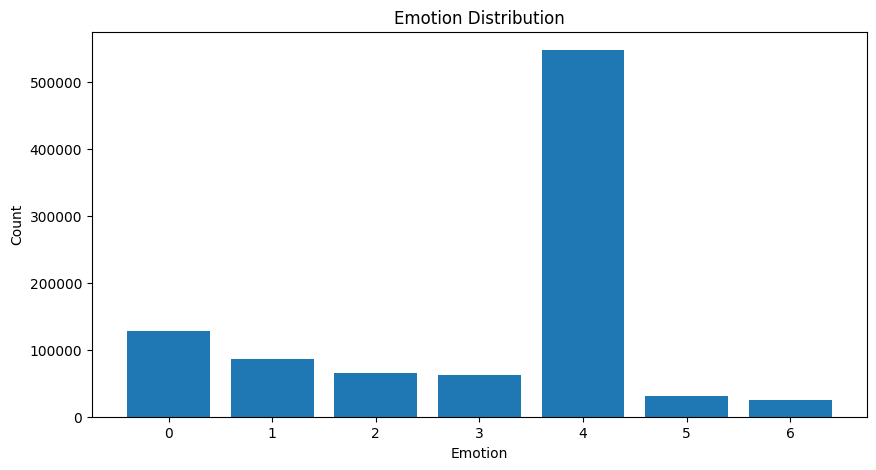

Emotion 0: 127312
Emotion 1: 86852
Emotion 2: 64628
Emotion 3: 62127
Emotion 4: 547130
Emotion 5: 30377
Emotion 6: 25290
Emotion 7: 0
Emotion 8: 0
Emotion 9: 0
Emotion 10: 0


In [4]:
# draw distribution of pitch and yaw 
import matplotlib.pyplot as plt



all_emos = all_emos[torch.randperm(all_emos.size(0))]
# picked_emos = all_emos[:3000]

plt.figure(figsize=(10, 5))
hist = {}
for emo in all_emos:
    hist[emo.item()] = hist.get(emo.item(), 0) + 1

plt.bar(hist.keys(), hist.values())
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Emotion Distribution')
plt.show()
    
for i in range(11):
    print(f"Emotion {i}: {hist.get(i, 0)}")

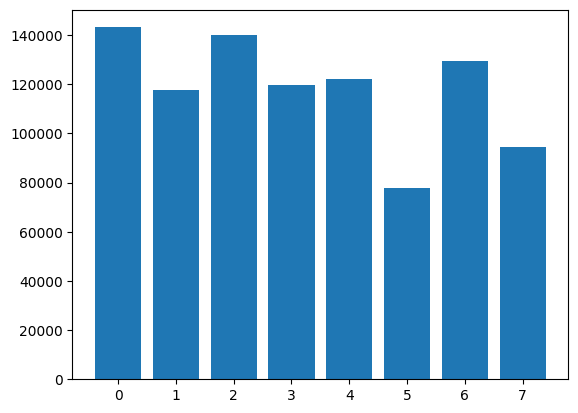

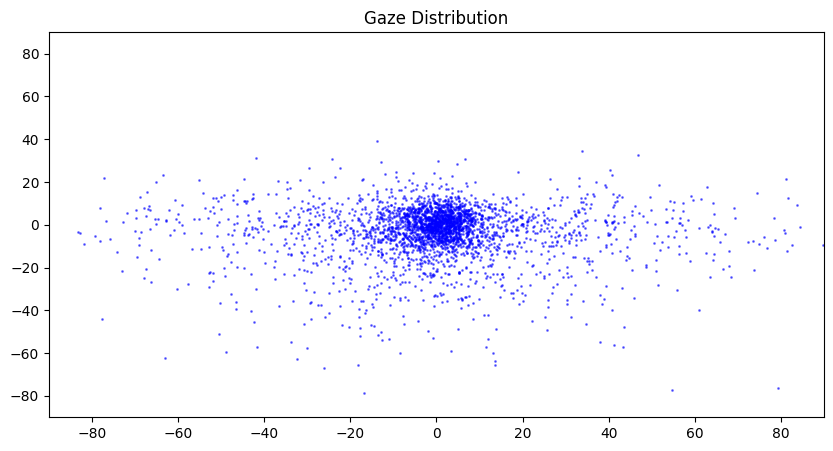

In [ ]:
# draw distribution of pitch and yaw 
import matplotlib.pyplot as plt


# all_angles = all_angles[:, -2:]
pitches = all_angles[:,0] / torch.pi * 180
yaws = all_angles[:,1] / torch.pi * 180

gaze_lbls = torch.zeros_like(pitches)
gaze_lbls += (pitches > 0).long() * 4
gaze_lbls += (yaws > 0).long() * 2
gaze_lbls += (abs(pitches)>abs(yaws)).long() * 1

hist = {}
for gaze_lbl in gaze_lbls:
    hist[gaze_lbl.item()] = hist.get(gaze_lbl.item(), 0) + 1
plt.bar(hist.keys(), hist.values())
plt.show()


# shuffle all_angles
all_angles_shuffled = all_angles[torch.randperm(all_angles.size(0))]
picked_angles = all_angles_shuffled[:3000]

plt.figure(figsize=(10, 5))
for angle in picked_angles:
    plt.scatter(angle[1] / torch.pi * 180, angle[0] / torch.pi * 180, s=1, c='blue', alpha=0.5)

# set the range of the scatters
plt.xlim(-90, 90)   # x轴范围从0到6
plt.ylim(-90, 90)  # y轴范围从0到12

plt.title('Gaze Distribution')
plt.show()
    
    


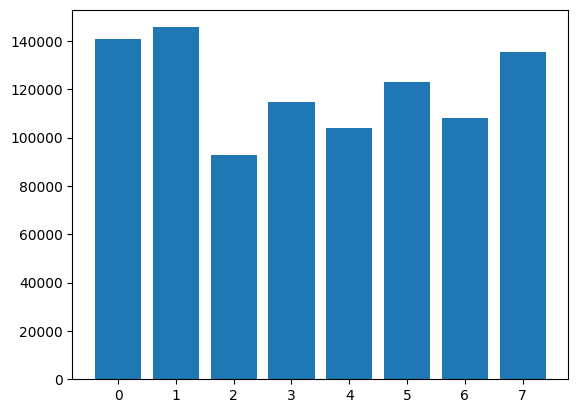

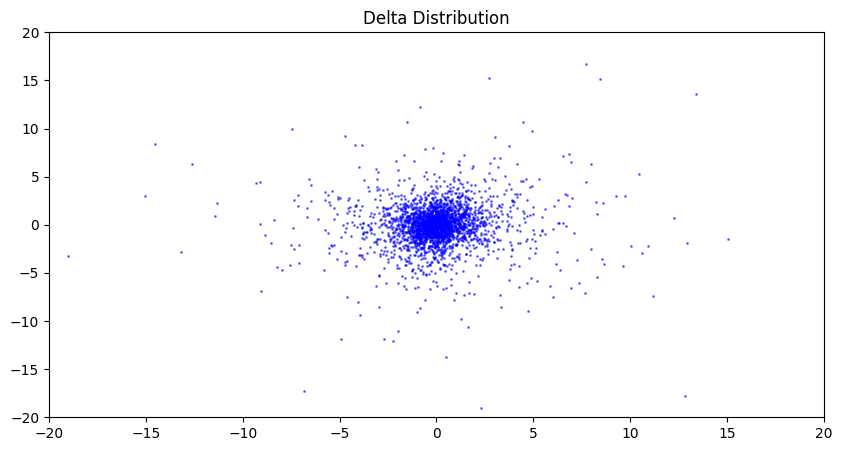

In [11]:
# draw distribution of delta pitch and yaw 
import matplotlib.pyplot as plt


# all_angles = all_angles[:, -2:]
pitches = all_angle_deltas[:,0] / torch.pi * 180
yaws = all_angle_deltas[:,1] / torch.pi * 180

gaze_lbls = torch.zeros_like(pitches)
gaze_lbls += (pitches > 0).long() * 4
gaze_lbls += (yaws > 0).long() * 2
gaze_lbls += (abs(pitches)>abs(yaws)).long() * 1

hist = {}
for gaze_lbl in gaze_lbls:
    hist[gaze_lbl.item()] = hist.get(gaze_lbl.item(), 0) + 1
plt.bar(hist.keys(), hist.values())
plt.show()


# shuffle all_angle_deltas
all_angle_deltas_shuffled = all_angle_deltas[torch.randperm(all_angle_deltas.size(0))]
picked_angles = all_angle_deltas_shuffled[:3000]

plt.figure(figsize=(10, 5))
for angle in picked_angles:
    plt.scatter(angle[1] / torch.pi * 180, angle[0] / torch.pi * 180, s=1, c='blue', alpha=0.5)

# set the range of the scatters
plt.xlim(-20, 20)   # x轴范围从0到6
plt.ylim(-20, 20)  # y轴范围从0到12

plt.title('Delta Distribution')
plt.show()
    
    


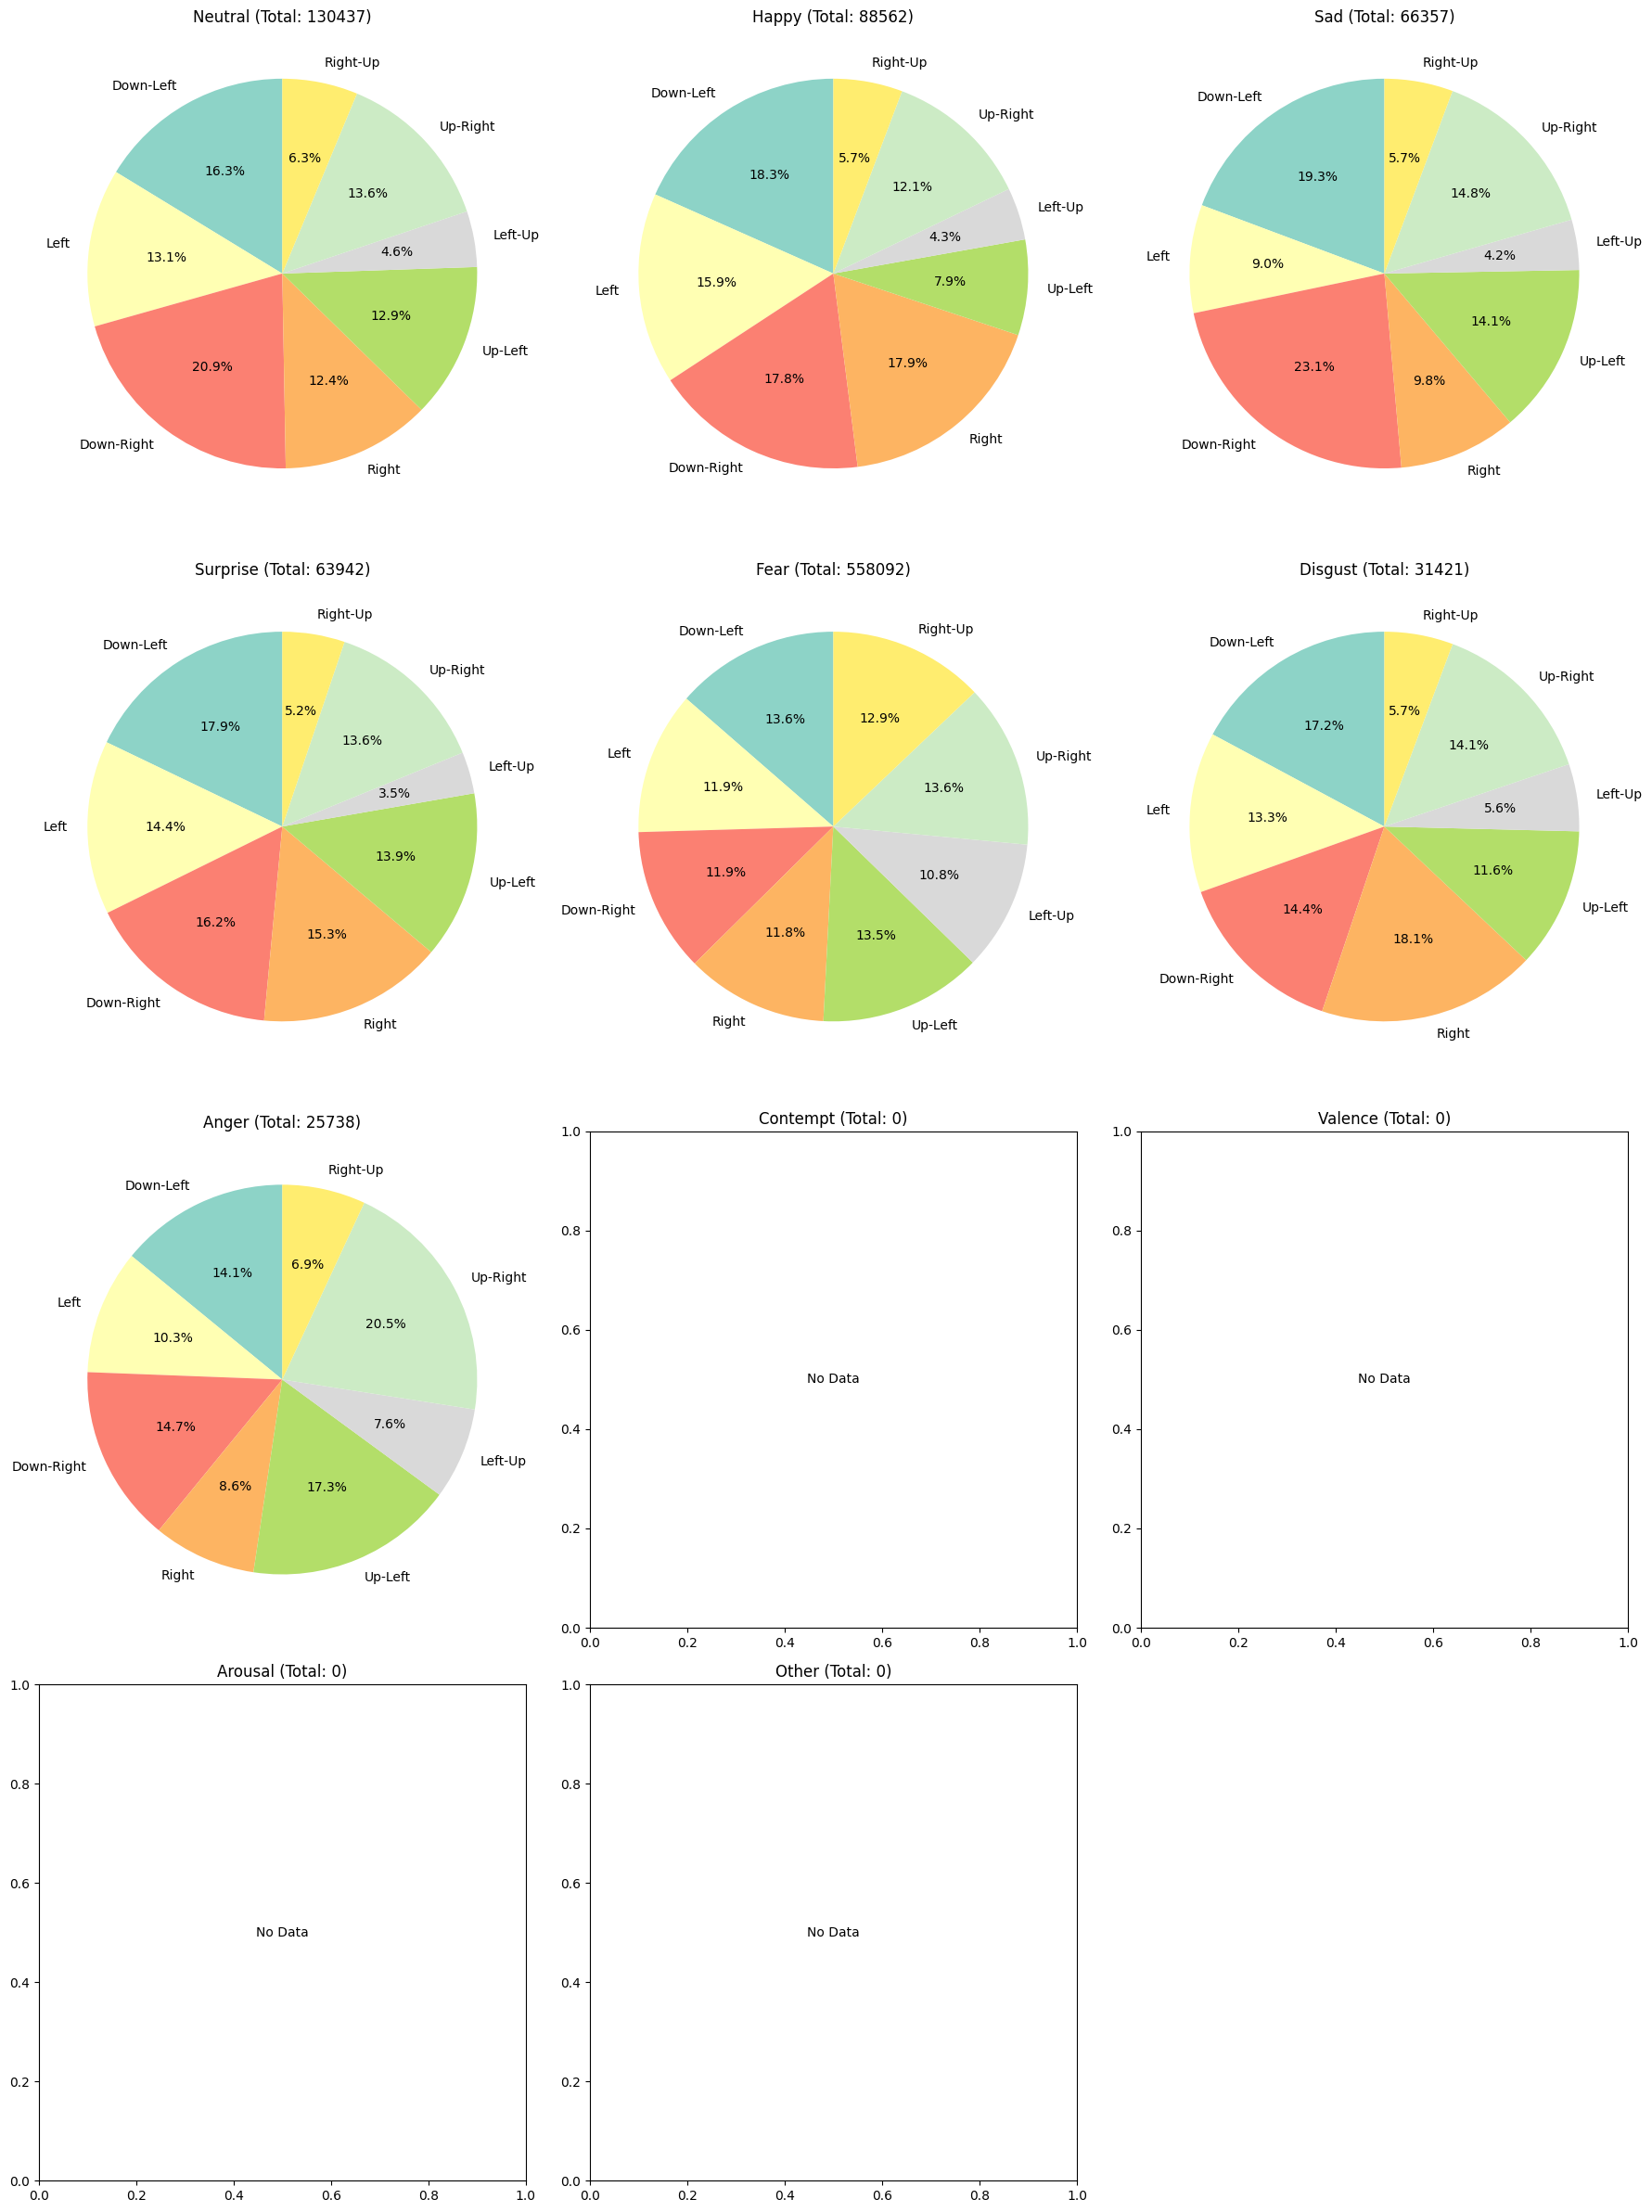

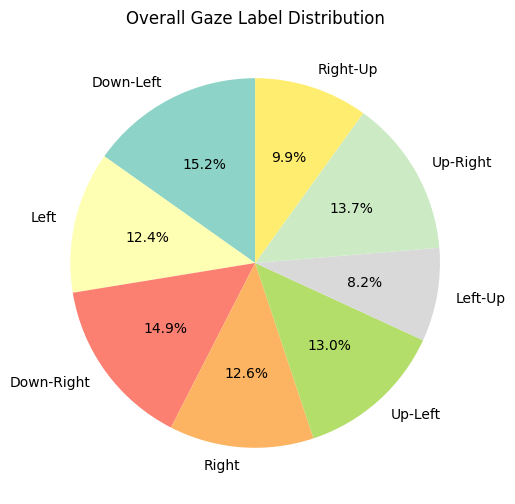

In [9]:
# draw distribution of pitch and yaw 
import matplotlib.pyplot as plt
import numpy as np

pitches = all_angles[:,0] / torch.pi * 180
yaws = all_angles[:,1] / torch.pi * 180

gaze_lbls = torch.zeros_like(pitches)
gaze_lbls += (pitches > 0).long() * 4
gaze_lbls += (yaws > 0).long() * 2
gaze_lbls += (abs(pitches)>abs(yaws)).long() * 1

# 收集数据
hist = {}
for i in range(len(all_emos)):
    emo = all_emos[i].item()
    gaze_lbl = gaze_lbls[i].item()  
    hist[(emo, gaze_lbl)] = hist.get((emo, gaze_lbl), 0) + 1

# 定义凝视标签的含义（用于图例）
gaze_labels = {
    0: 'Down-Left',    # pitch<0, yaw<0, |pitch|>|yaw|
    1: 'Left',         # pitch<0, yaw<0, |pitch|<|yaw|
    2: 'Down-Right',   # pitch<0, yaw>0, |pitch|>|yaw|
    3: 'Right',        # pitch<0, yaw>0, |pitch|<|yaw|
    4: 'Up-Left',      # pitch>0, yaw<0, |pitch|>|yaw|
    5: 'Left-Up',      # pitch>0, yaw<0, |pitch|<|yaw|
    6: 'Up-Right',     # pitch>0, yaw>0, |pitch|>|yaw|
    7: 'Right-Up'      # pitch>0, yaw>0, |pitch|<|yaw|
}

# 情感标签的含义（11个标签）
emotion_labels = {
    0: 'Neutral',
    1: 'Happy', 
    2: 'Sad',
    3: 'Surprise',
    4: 'Fear',
    5: 'Disgust',
    6: 'Anger',
    7: 'Contempt',
    8: 'Valence',
    9: 'Arousal',
    10: 'Other'
}

# 创建子图 - 调整为4行3列以容纳11个情感标签
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
axes = axes.flatten()

# 定义颜色
colors = plt.cm.Set3(np.linspace(0, 1, 8))

for now_emo in range(11):
    hist_emo = {}
    tot_count = 0
    for (emo_lbl, gaze_lbl), count in hist.items():
        if emo_lbl == now_emo:
            hist_emo[gaze_lbl] = count
            tot_count += count
    
    if tot_count > 0:
        # 按照凝视标签顺序排序（0-7）
        sorted_gaze_ids = sorted(hist_emo.keys())
        
        # 准备饼图数据，按排序后的顺序
        gaze_ids = sorted_gaze_ids
        counts = [hist_emo[gaze_id] for gaze_id in gaze_ids]
        labels = [gaze_labels.get(gaze_id, f'Gaze {gaze_id}') for gaze_id in gaze_ids]
        pie_colors = [colors[int(gaze_id)] for gaze_id in gaze_ids]
        
        # 画饼图
        axes[now_emo].pie(counts, labels=labels, colors=pie_colors, autopct='%1.1f%%', startangle=90)
        axes[now_emo].set_title(f'{emotion_labels.get(now_emo, f"Emotion {now_emo}")} (Total: {tot_count})')
    else:
        axes[now_emo].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[now_emo].transAxes)
        axes[now_emo].set_title(f'{emotion_labels.get(now_emo, f"Emotion {now_emo}")} (Total: 0)')

# 删除多余的子图（第12个位置）
axes[11].axis('off')

plt.tight_layout()
plt.show()

# 创建一个总体的凝视标签分布图例，也按顺序排序
fig, ax = plt.subplots(figsize=(10, 6))
all_gaze_hist = {}
for gaze_lbl in gaze_lbls:
    all_gaze_hist[gaze_lbl.item()] = all_gaze_hist.get(gaze_lbl.item(), 0) + 1

# 按凝视标签顺序排序
sorted_gaze_ids = sorted(all_gaze_hist.keys())
gaze_ids = sorted_gaze_ids
counts = [all_gaze_hist[gaze_id] for gaze_id in gaze_ids]
labels = [gaze_labels.get(gaze_id, f'Gaze {gaze_id}') for gaze_id in gaze_ids]
pie_colors = [colors[int(gaze_id)] for gaze_id in gaze_ids]

ax.pie(counts, labels=labels, colors=pie_colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Overall Gaze Label Distribution')
plt.show()

tensor([[ 0.0000,  0.0000],
        [ 0.0137, -0.0992],
        [ 0.0227, -0.1974],
        [-0.0165, -0.1042],
        [-0.0557, -0.0249]])
tensor([5., 5., 5., 5., 5.])


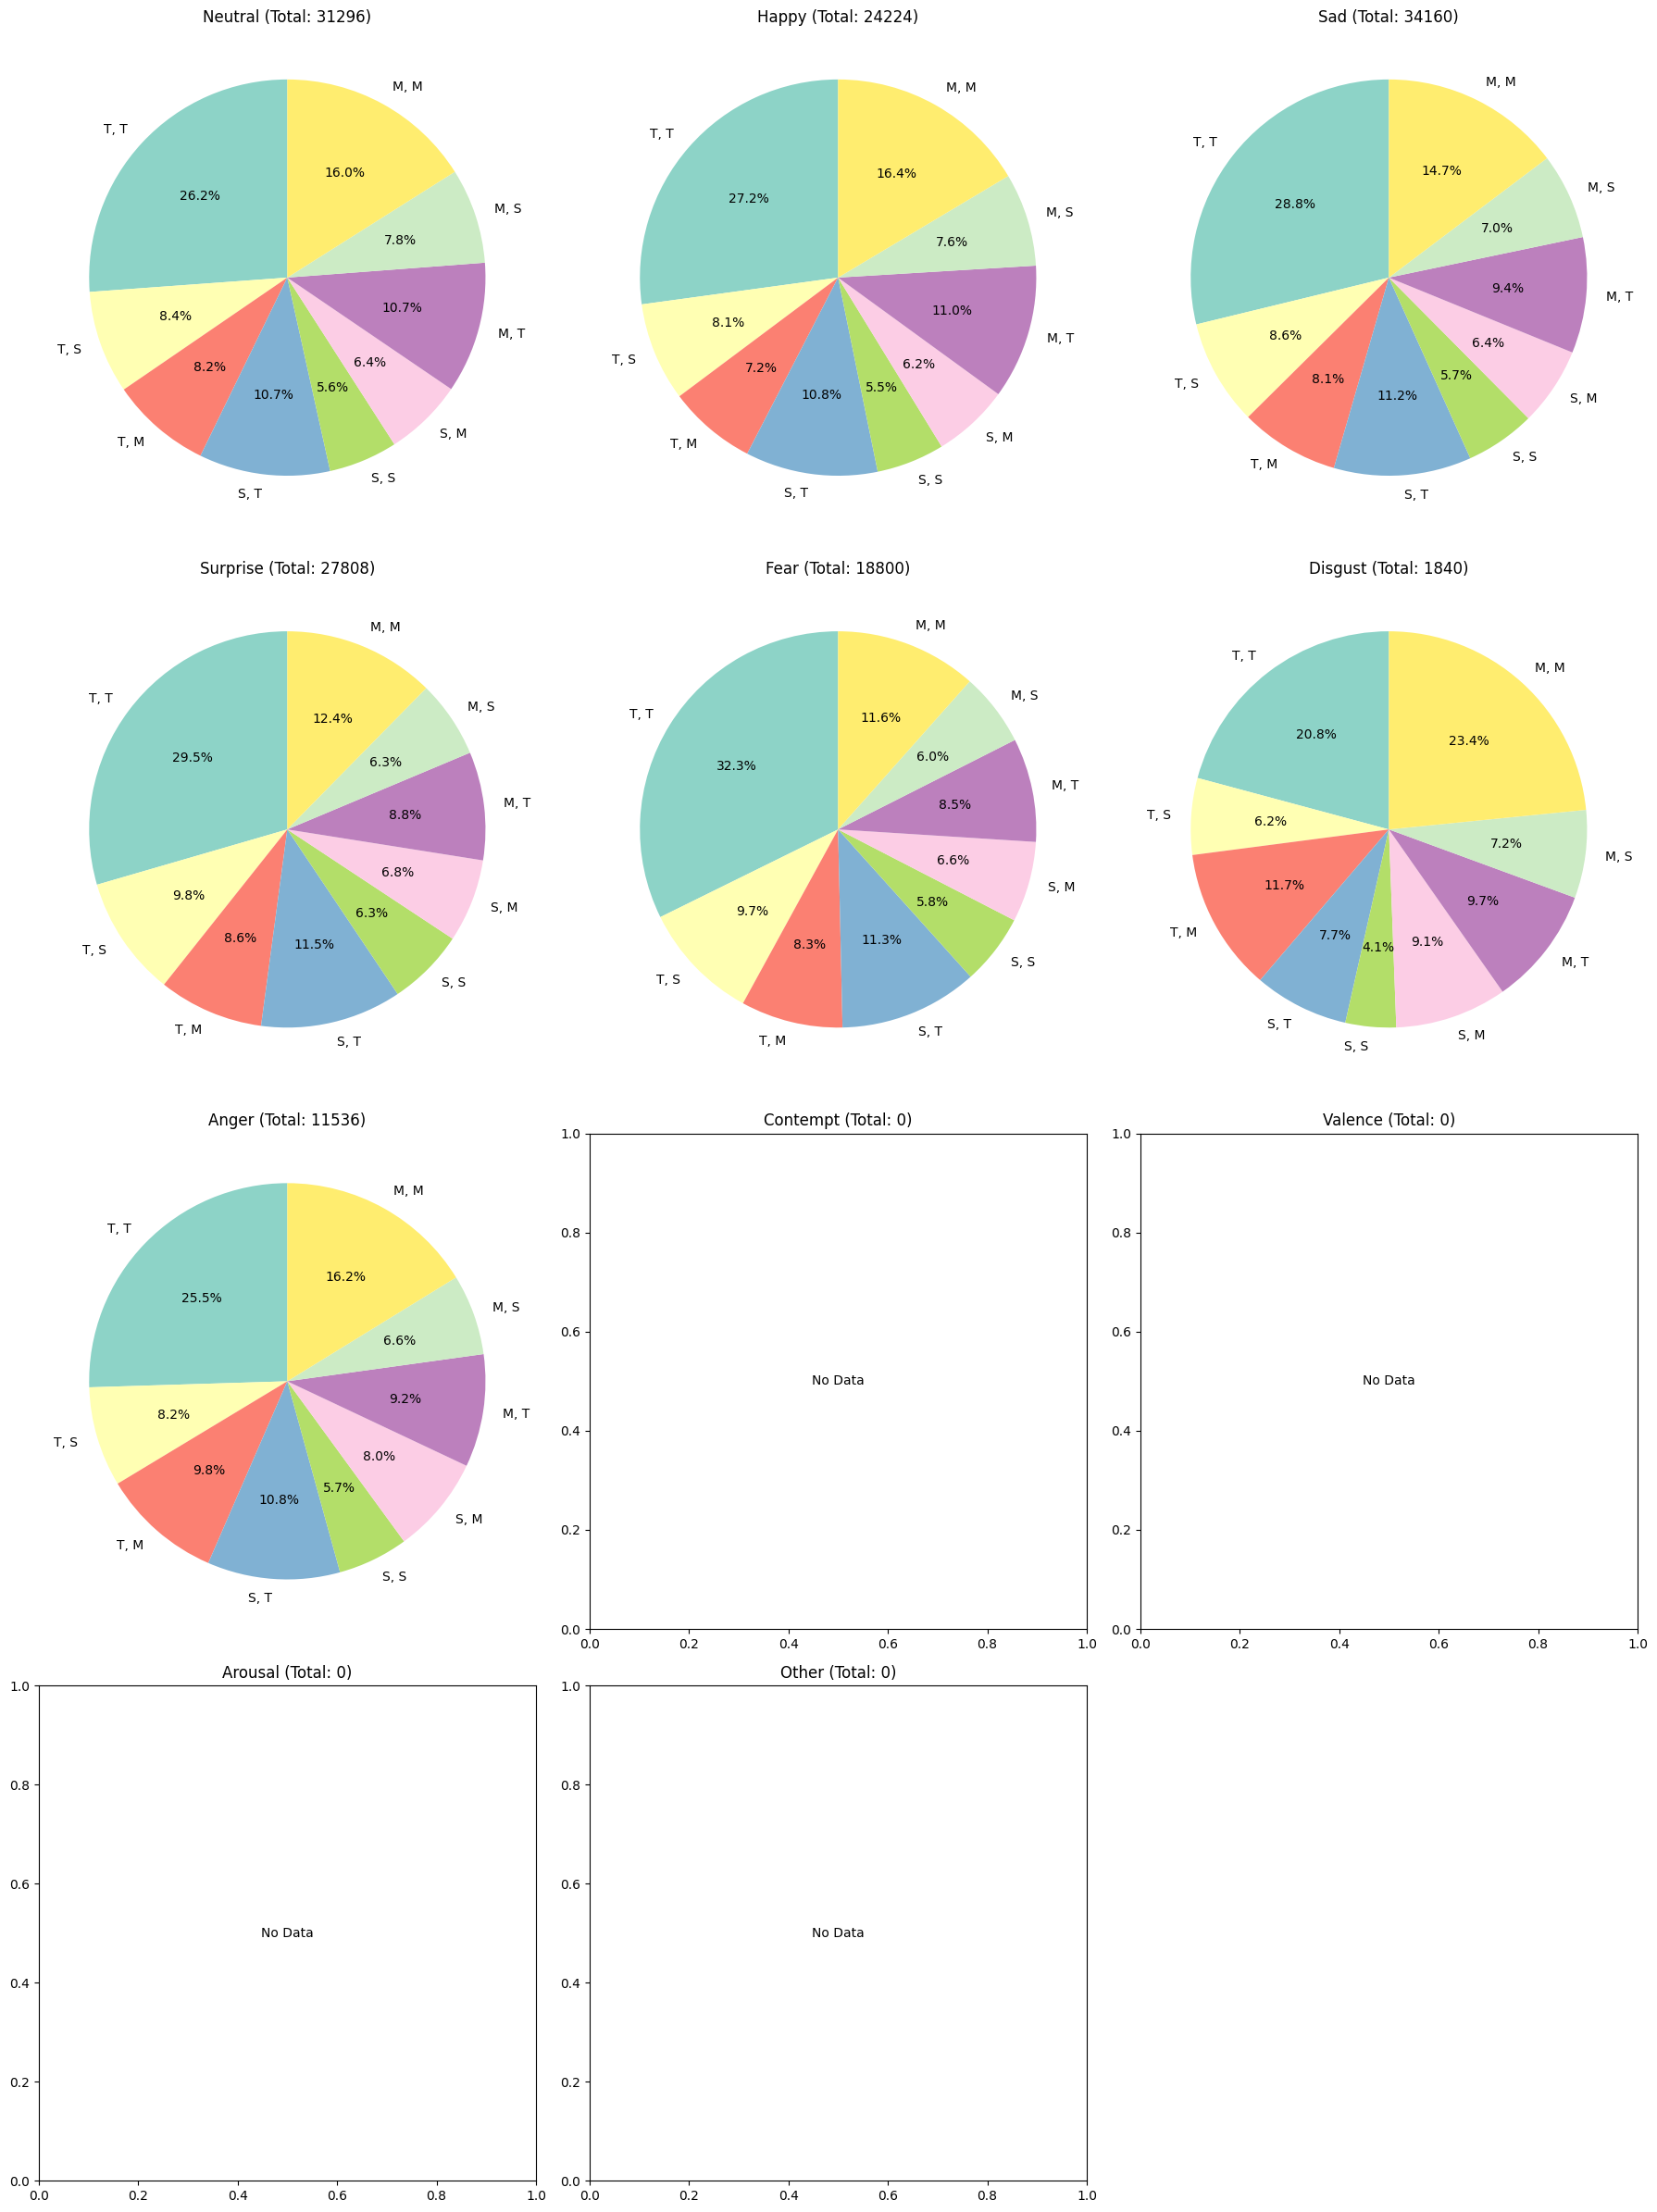

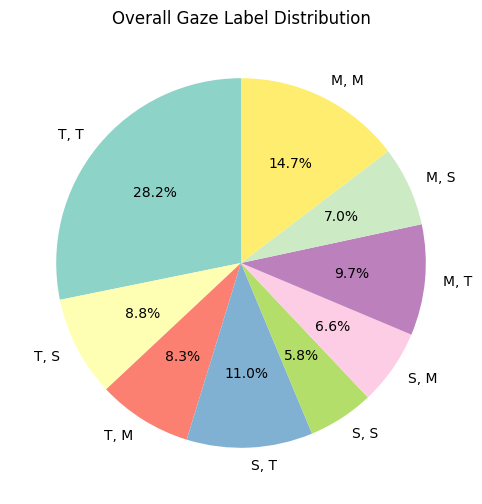

In [5]:
# 对一阶差分 (all_angle_deltas) 进行同样的分析
import matplotlib.pyplot as plt
import numpy as np

print(all_angle_deltas[:5])
print(all_emos[:5])

pitches = all_angle_deltas[:,0] / torch.pi * 180
yaws = all_angle_deltas[:,1] / torch.pi * 180

gaze_lbls = torch.zeros_like(pitches)
gaze_lbls += (torch.abs(pitches) > 1.0 ).long() * 3
gaze_lbls += (torch.abs(pitches) >= 2.0).long() * 3
gaze_lbls += (torch.abs(yaws) >  1.0 ).long() * 1
gaze_lbls += (torch.abs(yaws) >= 2.0 ).long() *1



# 收集数据
hist = {}
for i in range(len(all_emos)):
    emo = all_emos[i].item()
    gaze_lbl = gaze_lbls[i].item()  
    hist[(emo, gaze_lbl)] = hist.get((emo, gaze_lbl), 0) + 1

# 定义凝视标签的含义（用于图例）
gaze_labels = {
    0: 'T, T',
    1: 'T, S',
    2: 'T, M',
    3: 'S, T',
    4: 'S, S',
    5: 'S, M',
    6: 'M, T',
    7: 'M, S',
    8: 'M, M'
}

# 情感标签的含义（11个标签）
emotion_labels = {
    0: 'Neutral',
    1: 'Happy', 
    2: 'Sad',
    3: 'Surprise',
    4: 'Fear',
    5: 'Disgust',
    6: 'Anger',
    7: 'Contempt',
    8: 'Valence',
    9: 'Arousal',
    10: 'Other'
}

# 创建子图 - 调整为4行3列以容纳11个情感标签
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
axes = axes.flatten()

# 定义颜色
colors = plt.cm.Set3(np.linspace(0, 1, 9))

for now_emo in range(11):
    hist_emo = {}
    tot_count = 0
    for (emo_lbl, gaze_lbl), count in hist.items():
        if emo_lbl == now_emo:
            hist_emo[gaze_lbl] = count
            tot_count += count
    
    if tot_count > 0:
        # 按照凝视标签顺序排序（0-9）
        sorted_gaze_ids = sorted(hist_emo.keys())
        
        # 准备饼图数据，按排序后的顺序
        gaze_ids = sorted_gaze_ids
        counts = [hist_emo[gaze_id] for gaze_id in gaze_ids]
        labels = [gaze_labels.get(gaze_id, f'Gaze {gaze_id}') for gaze_id in gaze_ids]
        pie_colors = [colors[int(gaze_id)] for gaze_id in gaze_ids]
        
        # 画饼图
        axes[now_emo].pie(counts, labels=labels, colors=pie_colors, autopct='%1.1f%%', startangle=90)
        axes[now_emo].set_title(f'{emotion_labels.get(now_emo, f"Emotion {now_emo}")} (Total: {tot_count})')
    else:
        axes[now_emo].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[now_emo].transAxes)
        axes[now_emo].set_title(f'{emotion_labels.get(now_emo, f"Emotion {now_emo}")} (Total: 0)')

# 删除多余的子图（第12个位置）
axes[11].axis('off')

plt.tight_layout()
plt.show()

# 创建一个总体的凝视标签分布图例，也按顺序排序
fig, ax = plt.subplots(figsize=(10, 6))
all_gaze_hist = {}
for gaze_lbl in gaze_lbls:
    all_gaze_hist[gaze_lbl.item()] = all_gaze_hist.get(gaze_lbl.item(), 0) + 1

# 按凝视标签顺序排序
sorted_gaze_ids = sorted(all_gaze_hist.keys())
gaze_ids = sorted_gaze_ids
counts = [all_gaze_hist[gaze_id] for gaze_id in gaze_ids]
labels = [gaze_labels.get(gaze_id, f'Gaze {gaze_id}') for gaze_id in gaze_ids]
pie_colors = [colors[int(gaze_id)] for gaze_id in gaze_ids]

ax.pie(counts, labels=labels, colors=pie_colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Overall Gaze Label Distribution')
plt.show()

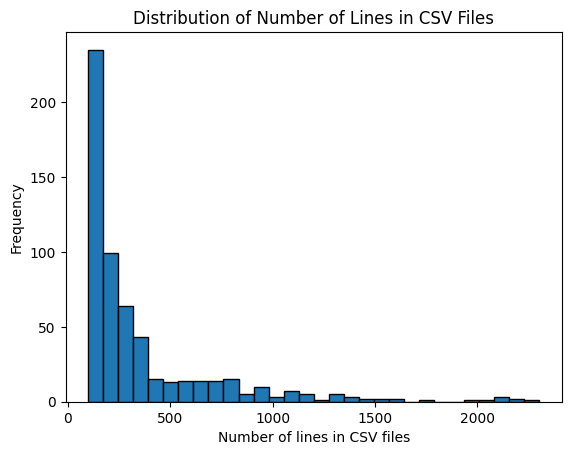

In [ ]:
import os
import matplotlib.pyplot as plt
csv_path = "/home/qzk/Facial-Foundation-Model/saved/data/GazeCapture/train"
len_lines = []
# with open(csv_path, 'r') as f:
#     lines = f.readlines()
#     len_lines.append(len(lines))
csv_paths = os.listdir(csv_path)
for path in csv_paths:
    if path.endswith('.csv'):
        with open(os.path.join(csv_path, path), 'r') as f:
            lines = f.readlines()
            len_lines.append(len(lines))
# print(len_lines)
plt.hist(len_lines, bins=30, edgecolor='black')
plt.xlabel('Number of lines in CSV files')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Lines in CSV Files')
plt.show()